## Modeling
In this notebook I test out different models and how they work on the dataset.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Import models from script folder
import sys
import os

# Add project root to Python path
sys.path.append(os.path.abspath('..'))

from script.helper_methods import data_preprocessing as dp
from script.helper_methods import data_visualization as dv
from script.helper_methods import data_modeling as dm

# Load Data

In [2]:
# load in the data
names = ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test']
data = dp.load_split_data(names, 'dataset1')
X_train, X_val, X_test, y_train, y_val, y_test = data['X_train'], data['X_val'], data['X_test'], data['y_train'], data['y_val'], data['y_test']

Load data with base name: dataset1


In [3]:
X_train.head()

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Flow rate (Mean)_rolling_mean_10,Flow rate (Mean)_rolling_min_10,Flow rate (Mean)_rolling_max_10,...,Temperature TS outlet (Mean)_rolling_max_10,Tank temperature (Mean)_rolling_min_10,Temperature TS inlet (Mean)_rolling_mean_10,Temperature TS inlet (Mean)_rolling_min_10,Temperature TS inlet (Mean)_rolling_max_10,Bypass temperature (Mean)_rolling_mean_10,Bypass temperature (Mean)_rolling_min_10,Bypass temperature (Mean)_rolling_max_10,Anomaly_rolling_mean_10,Anomaly_rolling_min_10
Elapsed_seconds,,,,,,,,,,,,,,,,,,,,,
0.00,3.769856,3.889634,3.855032,3.851540,-5.460454,-6.091803,0.705353,3.769459,3.772753,3.766175,...,-5.423086,-8.551531,-6.128507,-6.129919,-6.099743,0.705645,0.746385,0.665243,-0.110115,-0.10968
0.05,3.769399,3.912015,3.871879,3.880215,-5.522141,-6.117805,0.671511,3.769230,3.772295,3.766175,...,-5.423086,-8.623694,-6.141586,-6.156729,-6.099743,0.688717,0.712516,0.665243,-0.110115,-0.10968
0.10,3.769856,3.917416,3.901726,3.916645,-5.475141,-6.110376,0.710995,3.769307,3.772295,3.766175,...,-5.423086,-8.623694,-6.143455,-6.156729,-6.099743,0.696241,0.712516,0.670883,-0.110115,-0.10968
0.15,3.766881,3.888090,3.871879,3.874015,-5.486891,-6.114090,0.694072,3.768601,3.769778,3.766175,...,-5.423086,-8.623694,-6.145324,-6.156729,-6.099743,0.695771,0.712516,0.670883,-0.110115,-0.10968
0.20,3.766423,3.892720,3.889693,3.885644,-5.478079,-6.110376,0.705353,3.768086,3.769320,3.766175,...,-5.423086,-8.630255,-6.145697,-6.156729,-6.099743,0.697745,0.712516,0.670883,-0.110115,-0.10968


In [4]:
y_train.head()

,Plug_future
Elapsed_seconds,
0.00,0.0
0.05,0.0
0.10,0.0
0.15,0.0
0.20,0.0


### Baseline model

In [5]:
baseline = dm.baseline_model(X_train, y_train, X_val, y_val)

Validation F1 Score: 0.655
Validation set results (baseline):
              precision    recall  f1-score   support

         0.0      0.759     1.000     0.863      1188
         1.0      0.000     0.000     0.000       377

    accuracy                          0.759      1565
   macro avg      0.380     0.500     0.432      1565
weighted avg      0.576     0.759     0.655      1565



/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [6]:
dp.print_distribution(y_train, "Training set")

Training set distribution:
  Class 0.0: 278547 samples
  Class 1.0: 51233 samples


### Upsample values

In [7]:
X_train, y_train = ov.oversample_minority(
    X_train,
    y_train,
    target_ratio=1.0,       
    random_state=42
)

🪜 Oversampling minority class to balance dataset...
 - Original minority samples: 51233, majority samples: 278547
 - After oversampling: minority samples: 278547, majority samples: 278547
⚖️ Oversampling completed.


In [8]:
# Check class balance for the target variable
dp.print_distribution(y_train, "Training set")

Training set distribution:
  Class 0.0: 278547 samples
  Class 1.0: 278547 samples


### Combing train and val for visualization
Combining the two sets for visualization purposes later

In [9]:
X_train_val = pd.concat([X_train, X_val]).reset_index(drop=True)
y_train_val = pd.concat([y_train, y_val]).reset_index(drop=True)

X_train_val_unscaled = dp.descale_features(X_train_val)
X_train_val_unscaled = X_train_val_unscaled.reset_index(drop=True)
y_train_val = y_train_val.reset_index(drop=True)

X_train_val_unscaled["Plug"] = y_train_val
X_train_val_unscaled


⚙️ Features descaled using StandardScaler inverse transform


,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Flow rate (Mean)_rolling_mean_10,Flow rate (Mean)_rolling_min_10,Flow rate (Mean)_rolling_max_10,...,Tank temperature (Mean)_rolling_min_10,Temperature TS inlet (Mean)_rolling_mean_10,Temperature TS inlet (Mean)_rolling_min_10,Temperature TS inlet (Mean)_rolling_max_10,Bypass temperature (Mean)_rolling_mean_10,Bypass temperature (Mean)_rolling_min_10,Bypass temperature (Mean)_rolling_max_10,Anomaly_rolling_mean_10,Anomaly_rolling_min_10,Plug
0,2006.990755,0.663001,1.006496,1.122522,-6.231957,-6.309016,25.589479,2006.990755,2006.990755,2006.990755,...,-6.344172,-6.309016,-6.309016,-6.309016,25.589479,25.589479,25.589479,0.0,6.938894e-18,0.0
1,2006.802163,0.666047,1.010171,1.129320,-6.287087,-6.327391,25.573727,2006.896459,2006.802163,2006.990755,...,-6.373047,-6.318204,-6.327391,-6.309016,25.581603,25.573727,25.589479,0.0,6.938894e-18,0.0
2,2006.990755,0.666782,1.016682,1.137956,-6.245083,-6.322141,25.592105,2006.927891,2006.802163,2006.990755,...,-6.373047,-6.319516,-6.327391,-6.309016,25.585104,25.573727,25.592105,0.0,6.938894e-18,0.0
3,2005.764905,0.662791,1.010171,1.127850,-6.255584,-6.324766,25.584228,2006.637144,2005.764905,2006.990755,...,-6.373047,-6.320829,-6.327391,-6.309016,25.584885,25.573727,25.592105,0.0,6.938894e-18,0.0
4,2005.576313,0.663421,1.014057,1.130607,-6.247708,-6.322141,25.589479,2006.424978,2005.576313,2006.990755,...,-6.375672,-6.321091,-6.327391,-6.309016,25.585804,25.573727,25.592105,0.0,6.938894e-18,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558654,72.882089,0.057319,0.058061,0.093731,0.441374,-0.150564,26.476887,73.806191,72.316312,74.673716,...,-2.616700,-0.072862,-0.192566,0.022691,26.473211,26.455884,26.505767,0.0,6.938894e-18,1.0
558655,71.561943,0.066034,0.065097,0.098508,0.459751,-0.137439,26.455884,73.513873,71.561943,74.673716,...,-2.569450,-0.067349,-0.150564,0.022691,26.471636,26.455884,26.505767,0.0,6.938894e-18,1.0
558656,71.184758,0.063934,0.068142,0.105123,0.302237,-0.294944,26.534648,73.183837,71.184758,74.673716,...,-2.716449,-0.081787,-0.294944,0.022691,26.476100,26.455884,26.534648,0.0,6.938894e-18,1.0
558657,69.864612,0.071600,0.072237,0.094098,0.312738,-0.329070,26.487389,72.712356,69.864612,74.673716,...,-2.766324,-0.105150,-0.329070,0.022691,26.479250,26.455884,26.534648,0.0,6.938894e-18,1.0


# Supervised

## Finding the best model
Training and evaluating different models to find the best one.
Performing hyperparametersearch on the models to find the best hyperparameters as well.

In [25]:
y_train.value_counts(normalize=True)

Plug_future
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64

In [26]:
best_model = dm.find_best_model(X_train, y_train, X_val, y_val, verbose_level=2, visualize=False)


🔍 Tuning Random Forest...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expecte

[CV] END max_depth=10, max_features=0.3, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time=   1.6s


/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END max_depth=None, max_features=0.5, min_samples_leaf=4, min_samples_split=2, n_estimators=400; total time=   3.2s


...

[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=  50.6s


/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END max_depth=10, max_features=0.3, min_samples_leaf=4, min_samples_split=2, n_estimators=200; total time= 1.8min
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time= 1.1min
[CV] END max_depth=None, max_features=0.3, min_samples_leaf=1, min_samples_split=5, n_estimators=400; total time= 3.6min
[CV] END max_depth=40, max_features=0.3, min_samples_leaf=2, min_samples_split=2, n_estimators=400; total time= 1.2min
[CV] END max_depth=20, max_features=0.3, min_samples_leaf=2, min_samples_split=2, n_estimators=800; total time= 5.3min
[CV] END max_depth=40, max_features=0.3, min_samples_leaf=2, min_samples_split=2, n_estimators=400; total time= 2.3min
[CV] END max_depth=20, max_features=0.3, min_samples_leaf=2, min_samples_split=2, n_estimators=800; total time= 6.5min
[CV] END max_depth=40, max_features=0.3, min_samples_leaf=2, min_samples_split=2, n_estimators=400; total time= 2.7min


/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



Best parameters: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': None}
Best F1 score: 0.8660057274757517
Best Training F1 score: 0.9999122899758844
Best Random Forest model with params: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': None} achieved validation F1 Score: 0.8660

🔍 Tuning SVM...
Searching over 2 hyperparameter combinations...
Params: {'C': 1.0, 'kernel': 'linear'} | Validation F1 Score = 0.8188 | Training F1 Score = 0.9991
Params: {'C': 0.5, 'kernel': 'linear'} | Validation F1 Score = 0.8159 | Training F1 Score = 0.9989

✅ Best parameters found: {'C': 1.0, 'kernel': 'linear'}
Best validation F1 Score: 0.8188 | Training F1 Score = 0.9991
Best SVM model with params: {'C': 1.0, 'kernel': 'linear'} achieved validation F1 Score: 0.8188

🔍 Tuning XGBoost...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END base_score=0.5, colsample_bytree=1.0, gamm

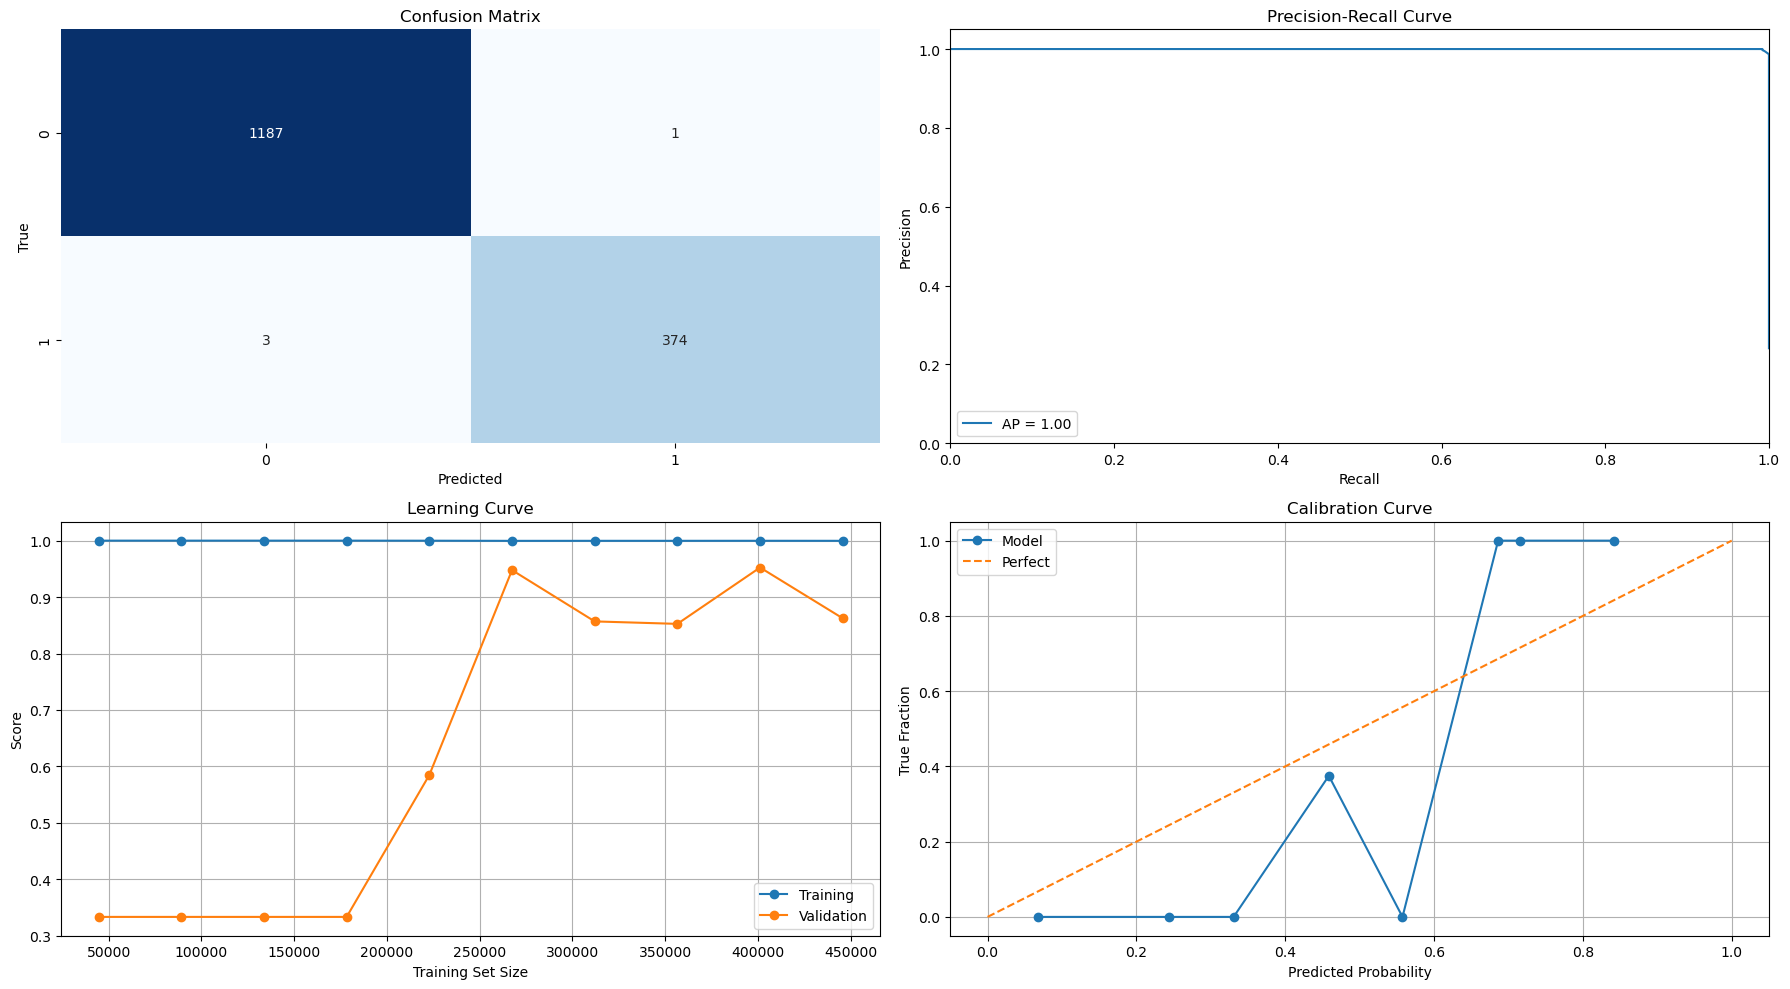

In [27]:
train_sizes, train_scores, val_scores = dm.get_learning_curve_data(best_model, X_train, y_train)
y_pred_proba = dv.get_y_scores(best_model, X_val)

dv.plot_all(best_model, X_val, y_val, train_sizes, train_scores, val_scores)

⚙️ Features descaled using StandardScaler inverse transform
anomalies Index(['Flow rate (Mean)', 'TS outlet pressure (Mean)',
       'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)',
       'Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)',
       'Bypass temperature (Mean)', 'Flow rate (Mean)_rolling_mean_10',
       'Flow rate (Mean)_rolling_min_10', 'Flow rate (Mean)_rolling_max_10',
       'TS outlet pressure (Mean)_rolling_mean_10',
       'TS outlet pressure (Mean)_rolling_min_10',
       'TS outlet pressure (Mean)_rolling_max_10',
       'TS inlet pressure (Mean)_rolling_mean_10',
       'TS inlet pressure (Mean)_rolling_min_10',
       'TS inlet pressure (Mean)_rolling_max_10',
       'Pump outlet pressure (Mean)_rolling_mean_10',
       'Pump outlet pressure (Mean)_rolling_min_10',
       'Pump outlet pressure (Mean)_rolling_max_10',
       'Temperature TS outlet (Mean)_rolling_mean_10',
       'Temperature TS outlet (Mean)_rolling_min_10',
       'Tempera

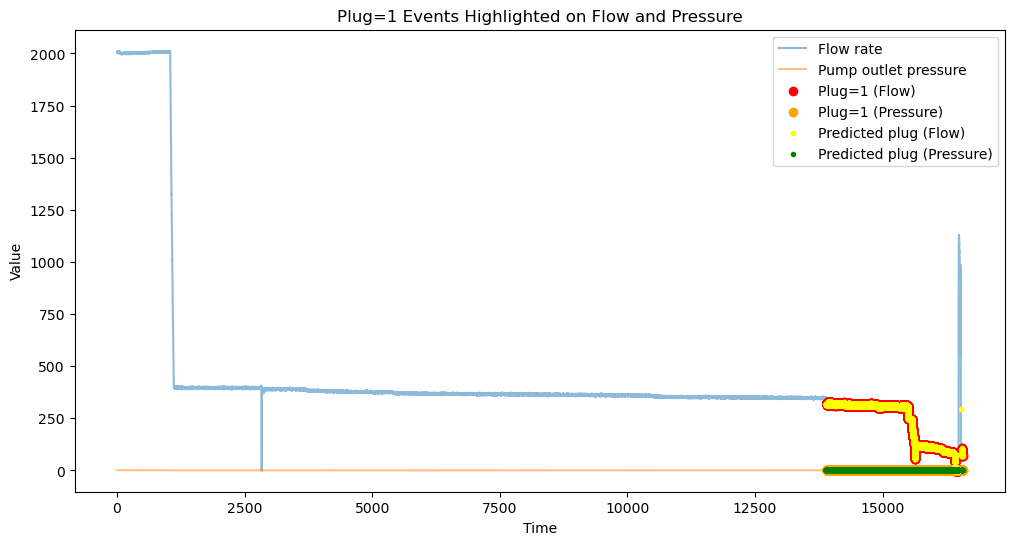

In [ ]:
X_all = pd.concat([X_train, X_val])
y_all = pd.concat([y_train, y_val])

y_pred = best_model.predict(X_all)

X_all_unscaled_part = dp.descale_features(X_all)

X_all_unscaled = X_all_unscaled_part.copy()
#X_all_unscaled['Plug'] = y_all #TODO: check if this is correct

dv.visualize_predicted_vs_true(X_all_unscaled, y_pred, anomalies=True)

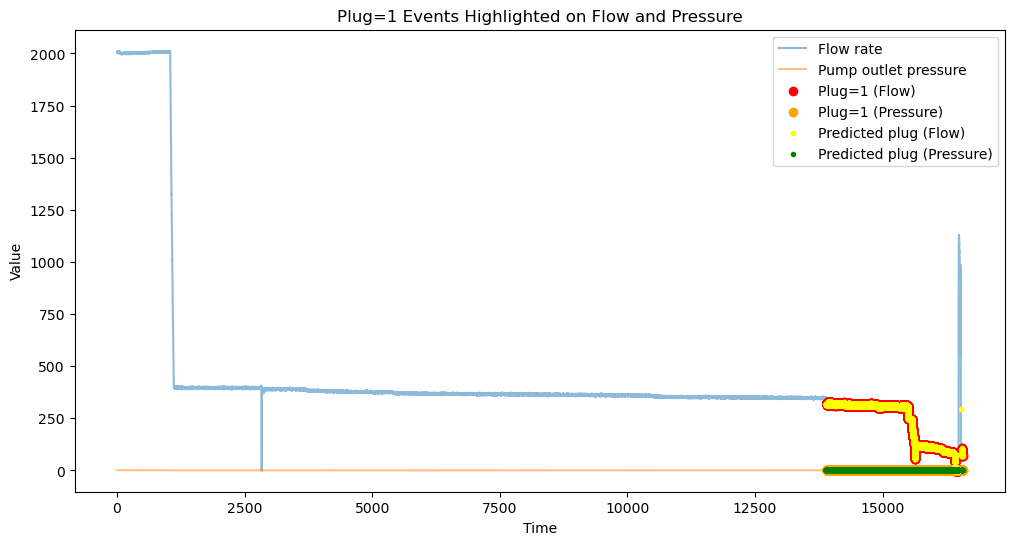

In [30]:
dv.visualize_predicted_vs_true(X_all_unscaled, y_pred, anomalies=False)

## Test best model on test dataset
Test the best model on the test dataset to check it´s generalization capabilities.

In [31]:
print(f"Evaluating best model ({best_model.__class__.__name__}) on test set:")
dm.retrain_final_model(X_train, X_val, y_train, y_val, best_model)
y_pred = dm.evaluate_model_on_test(best_model, X_test, y_test)

Evaluating best model (XGBClassifier) on test set:
[1 1 1 ... 1 1 1]
Test set results:
              precision    recall  f1-score   support

         1.0      1.000     1.000     1.000      1565

    accuracy                          1.000      1565
   macro avg      1.000     1.000     1.000      1565
weighted avg      1.000     1.000     1.000      1565

F1 Score: 1.0


## Save best model


In [ ]:
#NB! model_name = type(best_model).__name__, so it wont work with predict.py bc it uses best_model.joblib
# change to dm.save_model(best_model) if you want to save as best_model.joblib
# done so for testing different models in predict.py
dm.save_model(best_model, model_name=type(best_model).__name__)

TypeError: save_model() got an unexpected keyword argument 'model_name'

### Visualize performance

/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


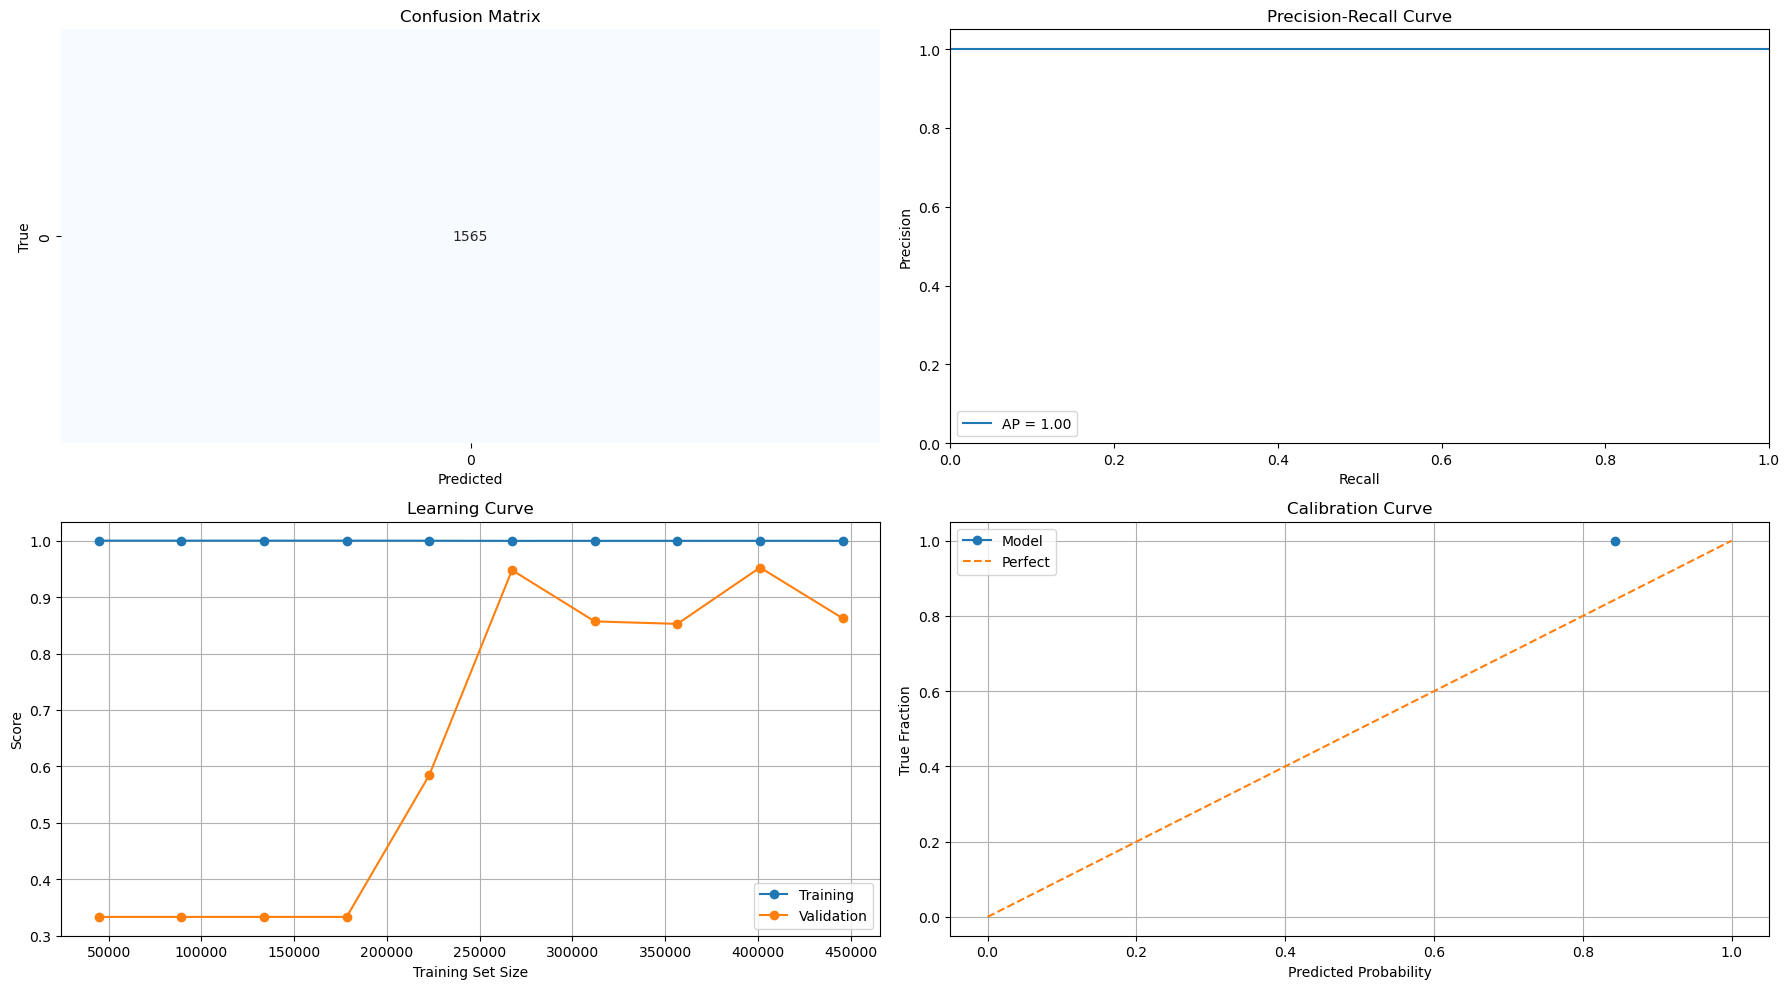

In [33]:
train_sizes, train_scores, val_scores = dm.get_learning_curve_data(best_model, X_train, y_train)
y_pred_proba = dv.get_y_scores(best_model, X_test)

dv.plot_all(best_model, X_test, y_test, train_sizes, train_scores, val_scores)

# TRAIN RANOM FOREST ON DATA    - AAAAA

In [2]:
# load best model
import joblib
model = joblib.load("../models/best_model.joblib")

print("Loaded model:", model)

Loaded model: RandomForestClassifier(class_weight='balanced', max_depth=5, max_features=0.2,
                       min_samples_leaf=2, min_samples_split=20,
                       random_state=42)


In [3]:
# new model with best params
from sklearn.ensemble import RandomForestClassifier as rfc
best_model = rfc(class_weight='balanced', max_depth=5, max_features=0.2,
                       min_samples_leaf=2, min_samples_split=20,
                       random_state=42)

In [4]:
LABLED_PATH = "../data/labeled/labeled_"

data = pd.read_csv(LABLED_PATH + 'data1.csv')

# Additional data to include in training
data5 = pd.read_csv(LABLED_PATH + "data5.csv")
data4 = pd.read_csv(LABLED_PATH + "data4.csv")
data7 = pd.read_csv(LABLED_PATH + "data7.csv")
data9 = pd.read_csv(LABLED_PATH + "data9.csv")
data11 = pd.read_csv(LABLED_PATH + "data11.csv")

In [6]:
X_train, X_test, y_train, y_test = dp.preprocess_data(data, "data1", additional_data=[data5, data4, data7, data9, data11], additional_data_name=["data5", "data4", "data7", "data9", "data11"], BASE_PATH = "../")

Base path /Users/karolinagil/Documents/Master/script/helper_methods
Adding physics features...
Adding time derivative features...
Created X with shape (332680, 285)
Created y with shape (332680,)
Window size: 40
Total signals: 57
X shape: (332680, 286)
y shape: (332680,)
Processing additional data: data5
Adding physics features...
Adding time derivative features...
Created X with shape (4142, 390)
Created y with shape (4142,)
Window size: 40
Total signals: 78
X shape: (4142, 391)
y shape: (4142,)
Processing additional data: data4
Adding physics features...
Adding time derivative features...
Created X with shape (9138, 270)
Created y with shape (9138,)
Window size: 40
Total signals: 54
X shape: (9138, 271)
y shape: (9138,)
Processing additional data: data7
Adding physics features...
Adding time derivative features...
Created X with shape (23147, 270)
Created y with shape (23147,)
Window size: 40
Total signals: 54
X shape: (23147, 271)
y shape: (23147,)
Processing additional data: data9


OSError: Cannot save file into a non-existent directory: '{'../data/processed_data'

In [ ]:
X_train.head()

,Flow rate (Mean)_mean,Flow rate (Mean)_std,Flow rate (Mean)_slope,TS outlet pressure (Mean)_std,TS outlet pressure (Mean)_slope,TS inlet pressure (Mean)_slope,Temperature TS outlet (Mean)_mean,Temperature TS outlet (Mean)_std,Temperature TS outlet (Mean)_slope,Tank temperature (Mean)_mean,...,Pressure before pump (Std Dev)_d2_mean,Pressure before pump (Std Dev)_d2_slope,Pressure after pump (Std Dev)_d1_mean,Pressure after pump (Std Dev)_d1_slope,Pressure after pump (Std Dev)_d2_mean,Pressure after pump (Std Dev)_d2_slope,Flow rate (Std Dev)_d1_mean,Flow rate (Std Dev)_d1_slope,Flow rate (Std Dev)_d2_mean,Flow rate (Std Dev)_d2_slope
0,3.656345,-0.045363,-0.045251,0.966618,-0.183076,-0.332107,-1.372138,-0.636813,0.399922,-1.495586,...,0.000587,-0.000009,-0.000346,0.000095,0.001491,0.000018,0.001557,-0.000024,-0.003017,0.000013
1,3.656182,-0.035869,-0.062709,0.971968,-0.222580,-0.359010,-1.372028,-0.630676,0.683051,-1.495461,...,0.000587,-0.000009,-0.000346,0.000095,0.001491,0.000018,0.001557,-0.000024,-0.003017,0.000013
2,3.656031,-0.027159,-0.080600,0.970358,-0.168395,-0.339462,-1.372075,-0.625364,0.107317,-1.495686,...,0.000587,-0.000009,-0.000346,0.000095,0.001491,0.000018,0.001557,-0.000024,-0.003017,0.000013
3,3.655784,-0.007695,-0.106598,1.000105,-0.232502,-0.359353,-1.371824,-0.612722,0.366956,-1.495211,...,0.000587,-0.000009,-0.000346,0.000095,0.001491,0.000018,0.001557,-0.000024,-0.003017,0.000013
4,3.655650,0.003505,-0.135700,1.000288,-0.237228,-0.394617,-1.372311,-0.554674,-0.273894,-1.495861,...,0.000587,-0.000009,-0.000346,0.000095,0.001491,0.000018,0.001557,-0.000024,-0.003017,0.000013


In [ ]:
print("Feautre sum", len(X_train.columns))



Feautre sum 190


In [ ]:
# train the model
best_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5, max_features=0.2,
                       min_samples_leaf=2, min_samples_split=20,
                       random_state=42)

In [ ]:
# predict on traning data
train_pred = best_model.predict(X_train)
train_pred_proba = best_model.predict_proba(X_train)[:, 1]
train_precision = precision_score(y_train, train_pred)
train_recall = recall_score(y_train, train_pred)
train_f1 = f1_score(y_train, train_pred)
train_precision, train_recall, train_f1, train_pred_proba

(0.9971567885590963,
 1.0,
 0.9985763704396213,
 array([0.00184859, 0.00186572, 0.00184859, ..., 0.96055547, 0.97273132,
        0.97011446]))

In [ ]:
# predict on test set
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_precision, test_recall, test_f1, y_pred_proba

/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


(0.0,
 0.0,
 0.0,
 array([0.12718838, 0.12718838, 0.12718838, ..., 0.2902791 , 0.2902791 ,
        0.2902791 ]))

In [ ]:
data3 = pd.read_csv(LABLED_PATH + "data3.csv")
data6 = pd.read_csv(LABLED_PATH + "data6.csv")
data8 = pd.read_csv(LABLED_PATH + "data8.csv")
data10 = pd.read_csv(LABLED_PATH + "data10.csv")

X3, y3, unscaled_X = dp.preprocess_data_predict(data3, dataset_name="data3")
X6, y6, unscaled_X = dp.preprocess_data_predict(data6, dataset_name="data6")
X8, y8, unscaled_X = dp.preprocess_data_predict(data8, dataset_name="data8")
X10, y10, unscaled_X = dp.preprocess_data_predict(data10, dataset_name="data10")

Adding physics features...
Adding time derivative features...


/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/numpy/_core/_methods.py:194: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/numpy/_core/_methods.py:136: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/numpy/_core/_methods.py:173: RuntimeWarning: invalid value encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)


Created X with shape (6203, 405)
Created y with shape (6203,)
Window size: 40
Total signals: 81
X shape: (6203, 406)
y shape: (6203,)
columns before numeric (0): 0       3
1       3
2       3
3       3
4       3
       ..
6198    3
6199    3
6200    3
6201    3
6202    3
Name: LogId, Length: 6203, dtype: category
Categories (1, int64): [3]


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Flow rate (Std Dev)_max
- Flow rate (Std Dev)_min
- Flow_Sensitivity_std
- Temperature TS inlet (Std Dev)_std
Feature names seen at fit time, yet now missing:
- Anomaly_d1_max
- Anomaly_d1_min
- Anomaly_d1_slope
- Anomaly_d2_mean
- Anomaly_d2_slope
- ...


In [ ]:
data12 = pd.read_csv(LABLED_PATH + "data12.csv")

X, y, unscaled_X = dp.preprocess_data_predict(data12, dataset_name="data12")

Created X with shape (16554, 40)
Created y with shape (16554,)
Window size: 40
Total signals: 8
X shape: (16554, 41)
y shape: (16554,)
columns before numeric (0): 0        12.0
1        12.0
2        12.0
3        12.0
4        12.0
         ... 
16549    12.0
16550    12.0
16551    12.0
16552    12.0
16553    12.0
Name: LogId, Length: 16554, dtype: category
Categories (1, float64): [12.0]
columns after numeric (1): 0        12.0
1        12.0
2        12.0
3        12.0
4        12.0
         ... 
16549    12.0
16550    12.0
16551    12.0
16552    12.0
16553    12.0
Name: LogId, Length: 16554, dtype: category
Categories (1, float64): [12.0]


In [ ]:
# pred on new data
y_pred = best_model.predict(X)
y_pred_proba = best_model.predict_proba(X)[:, 1]
new_precision = precision_score(y, y_pred)
new_recall = recall_score(y, y_pred)
new_f1 = f1_score(y, y_pred)
new_precision, new_recall, new_f1, y_pred_proba

(0.0912351490697153,
 0.14220824598183088,
 0.11115662979653147,
 array([0.36017023, 0.36017023, 0.36017023, ..., 0.50161801, 0.50161801,
        0.50161801]))

In [ ]:
# pred on new data
y_pred_3 = best_model.predict(X3)
y_pred_6 = best_model.predict(X6)
y_pred_8 = best_model.predict(X8)
y_pred_10 = best_model.predict(X10)

In [ ]:
from sklearn.metrics import classification_report
print("Classification Report for data3:")
print(classification_report(y3, y_pred_3))
print("Classification Report for data6:")
print(classification_report(y6, y_pred_6))
print("Classification Report for data8:")
print(classification_report(y8, y_pred_8))
print("Classification Report for data10:")
print(classification_report(y10, y_pred_10))


Classification Report for data3:
              precision    recall  f1-score   support

         0.0       0.64      1.00      0.78      3955
         1.0       0.00      0.00      0.00      2248

    accuracy                           0.64      6203
   macro avg       0.32      0.50      0.39      6203
weighted avg       0.41      0.64      0.50      6203

Classification Report for data6:
              precision    recall  f1-score   support

         0.0       1.00      0.91      0.96      1995
         1.0       0.00      0.00      0.00         0

    accuracy                           0.91      1995
   macro avg       0.50      0.46      0.48      1995
weighted avg       1.00      0.91      0.96      1995

Classification Report for data8:
              precision    recall  f1-score   support

         0.0       0.92      0.44      0.60      2203
         1.0       0.29      0.85      0.43       576

    accuracy                           0.53      2779
   macro avg       0.60      

/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/

In [ ]:
print("f1 Report for data3:")
print(f1_score(y3, y_pred_3))
print("f1 Report for data6:")
print(f1_score(y6, y_pred_6))
print("f1 Report for data8:")
print(f1_score(y8, y_pred_8))
print("f1 Report for data10:")
print(f1_score(y10, y_pred_10))

f1 Report for data3:
0.0
f1 Report for data6:
0.0
f1 Report for data8:
0.42894507410636445
f1 Report for data10:
0.014598540145985401
